# Pipeline de Poda Estruturada — MLP no CIFAR-10

**Objetivo:** Comparar **Poda Estruturada Local** vs **Poda Estruturada Global** utilizando critérios de saliência por magnitude (**Normas L1 e L2**) numa rede MLP (*Multi-Layer Perceptron*) totalmente ligada, validando o impacto e a resiliência de duas abordagens de remoção: **Poda One-Shot** e **Poda Iterativa (Progressiva)** ao longo de múltiplos níveis de esparsidade.

Este notebook implementa:

1. **Configuração e Importações** — Inicialização do ambiente, garantia de reprodutibilidade com sementes fixas e monitorização da pegada de VRAM.
2. **Estimativa de Saliência por Magnitude** — Implementação e comparação das funções de importância baseadas nas Normas L1 (Soma de Manhattan) e L2 (Magnitude Euclidiana) para os neurónios.
3. **Reconstrução Física das Camadas** — Algoritmo de manipulação in-place de tensores que reconstrói dinamicamente a arquitetura da rede, ajustando caminhos adjacentes (`Linear` e `BatchNorm1d`) sem recorrer a máscaras de zeros.
4. **Estratégias de Controlo da Poda** — Orquestração de dois fluxos experimentais:
   * **One-Shot:** Remoção integral e imediata da esparsidade alvo seguida de re-otimização.
   * **Iterativa (Progressiva):** Remoção faseada em múltiplos sub-passos com recalibração matemática do rácio relativo remanescente e aplicação de épocas adaptativas.
5. **Ajuste Fino (*Fine-Tuning*)** — Ciclos rápidos de recuperação pós-poda utilizando o otimizador SGD com Momentum e barra de progresso `tqdm` integrada por lote.
6. **Pipeline Experimental Automatizado** — Execução em bloco de todas as permutações de testes cruzando Métodos × Normas × Estratégias para rácios de 10% a 70%.
7. **Avaliação Global e Visualização** — Consolidação dos resultados num DataFrame estilizado do Pandas e geração de três gráficos comparativos integrados (Curva de Degradação de Exatidão, Redução de Latência e Eficiência de Compressão vs Speedup).

---
## 1. Setup e Importações

Carregamento de todas as dependências, importação das arquiteturas e métricas de `utils.py`, e configuração do dispositivo de computação com tracking inicial de memória VRAM.

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import numpy as np
import random
import copy
import time
from pathlib import Path
from tqdm import tqdm
from torch.utils.data import DataLoader, Subset

# ── Importações do utils.py ──
from utils import (
    CIFAR10MLP,
    evaluate_model,
    compute_metrics,
    train_model,
    classes
)

# ── Reprodutibilidade ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Dispositivo (foco em CUDA) ──
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

if device.type == "cuda":
    torch.cuda.reset_peak_memory_stats()
    vram_initial = torch.cuda.memory_allocated(device) / (1024**2)
    print(f"GPU: {torch.cuda.get_device_name(device)}")
    print(f"VRAM alocada inicialmente: {vram_initial:.2f} MB")
else:
    print("AVISO: CUDA não disponível. Os resultados de VRAM serão 0.")

Device: cpu
AVISO: CUDA não disponível. Os resultados de VRAM serão 0.


### Carregamento de Dados — Split Determinístico

Para garantir uma comparação justa entre as experiências de poda, reutilizamos o split
determinístico treino/validação gerado durante o treino do baseline.

In [14]:
transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616)
    )
])

full_trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)
testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

# Reutilizar o split determinístico guardado
split = torch.load("data/cifar10_split.pt", weights_only=False)
train_indices = split["train_indices"]
val_indices = split["val_indices"]

trainset = Subset(full_trainset, train_indices)
valset = Subset(full_trainset, val_indices)

batch_size = 64
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
valloader = DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Train: {len(trainset):,} | Val: {len(valset):,} | Test: {len(testset):,}")

Train: 42,500 | Val: 7,500 | Test: 10,000


### Carregamento do Modelo Baseline

Carregamento do MLP pré-treinado no CIFAR-10. Este modelo serve como ponto de referência
para todas as experiências de poda subsequentes.

In [15]:
models_dir = Path('model_dir')
PATH_MLP = models_dir / 'cifar_mlp.pt'

baseline_model = torch.load(PATH_MLP, map_location=torch.device('cpu'), weights_only=False) 
baseline_model = baseline_model.to(device)
baseline_model.eval()

print(baseline_model)
print(f"\nTotal de parâmetros: {sum(p.numel() for p in baseline_model.parameters()):,}")

if device.type == "cuda":
    vram_model = torch.cuda.memory_allocated(device) / (1024**2)
    print(f"VRAM após carregar modelo: {vram_model:.2f} MB")

CIFAR10MLP(
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=2048, bias=True)
    (2): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=2048, out_features=1024, bias=True)
    (6): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=1024, out_features=512, bias=True)
    (10): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): ReLU()
    (12): Dropout(p=0.2, inplace=False)
    (13): Linear(in_features=512, out_features=10, bias=True)
  )
)

Total de parâmetros: 8,928,778


---
## 2. Funções de Saliência para Estimativa de Importância dos Neurónios

A saliência de cada neurónio é calculada com base na norma dos seus pesos.
Neurónios com menor saliência são considerados menos importantes e são candidatos à remoção.

Para o neurónio $j$ na camada com pesos $W$:

**Norma L1:**  $S_j = \sum_i |w_{ij}|$

**Norma L2:**  $S_j = \sqrt{\sum_i w_{ij}^2}$

In [16]:
def compute_l1_saliency(layer: nn.Linear) -> torch.Tensor:
    """
    Saliência baseada na Norma L1 dos pesos de saída.
    
    Para o neurónio j:  S_j = Σ_i |w_{ij}|
    
    Neurónios com menor saliência são considerados menos importantes.
    """
    W = layer.weight.data  # Shape: [out_features, in_features]
    saliency = torch.sum(torch.abs(W), dim=1)  # L1 por neurónio
    return saliency


def compute_l2_saliency(layer: nn.Linear) -> torch.Tensor:
    """
    Saliência baseada na Norma L2 dos pesos de saída.
    
    Para o neurónio j:  S_j = sqrt(Σ_i w_{ij}²)
    """
    W = layer.weight.data
    saliency = torch.norm(W, p=2, dim=1)
    return saliency

def compute_l1_saliency(layer: nn.Linear) -> torch.Tensor:
    return torch.sum(torch.abs(layer.weight.data), dim=1)

def compute_l2_saliency(layer: nn.Linear) -> torch.Tensor:
    return torch.norm(layer.weight.data, p=2, dim=1)

def compute_taylor_saliency(model: nn.Module, layer: nn.Module, calibration_loader: DataLoader, device: torch.device) -> torch.Tensor:
    """Implementação  S_j = |(dL/da_j) * a_j|"""
    activations = []
    gradients = []
    
    # Hooks para extrair ativações e gradientes internamente
    def f_hook(module, input, output): activations.append(output.detach())
    def b_hook(module, grad_in, grad_out): gradients.append(grad_out[0].detach())
    
    h_f = layer.register_forward_hook(f_hook)
    h_b = layer.register_full_backward_hook(b_hook)
    
    # Forward e Backward com apenas 1 batch de treino (Calibração)
    model.eval()
    images, labels = next(iter(calibration_loader))
    outputs = model(images.to(device))
    loss = nn.CrossEntropyLoss()(outputs, labels.to(device))
    model.zero_grad()
    loss.backward()
    
    h_f.remove()
    h_b.remove()
    
    # Saliência baseada em Taylor (Média ao longo do lote)
    act = activations[0]
    grad = gradients[0]
    return (act * grad).abs().mean(dim=0)

print("Funções de saliência definidas: compute_l1_saliency, compute_l2_saliency")

Funções de saliência definidas: compute_l1_saliency, compute_l2_saliency


### Reconstrução Física das Camadas (In-Place Tensor Manipulation)

Em vez de mascarar pesos a zero, a arquitetura da rede é **fisicamente reconstruída**.
Isto garante que as matrizes de pesos continuam a multiplicar corretamente após a poda,
ajustando dinamicamente `in_features` e `out_features` das camadas subsequentes.

Isto reduz:
- Contagem de parâmetros
- Consumo de memória
- Latência de inferência

In [17]:
def apply_layer_pruning_physical(
    classifier: nn.Sequential,
    layer_idx: int,
    indices_to_keep: torch.Tensor
):
    """
    Remove fisicamente neurónios de uma camada Linear alvo e propaga as
    alterações dimensionais para as camadas adjacentes (BatchNorm + próxima Linear).
    
    Esta é PODA ESTRUTURADA REAL — a arquitetura é fisicamente reconstruída,
    reduzindo contagem de parâmetros, memória e latência de inferência.
    
    Garante o ajuste dinâmico de in_features e out_features para que as
    matrizes continuem a multiplicar corretamente.
    
    Args:
        classifier: nn.Sequential contendo todas as camadas
        layer_idx:  Índice da camada Linear a podar
        indices_to_keep: Tensor 1D com índices dos neurónios a reter
    """
    layer = classifier[layer_idx]
    indices_to_keep = torch.sort(indices_to_keep).values
    num_to_keep = len(indices_to_keep)
    
    # Podar a dimensão de saída da camada alvo
    # Selecionar apenas as linhas (neurónios) a manter
    layer.weight = nn.Parameter(layer.weight.data[indices_to_keep, :])
    if layer.bias is not None:
        layer.bias = nn.Parameter(layer.bias.data[indices_to_keep])
    layer.out_features = num_to_keep
    
    #Propagar para camadas downstream (BatchNorm)
    next_linear_idx = None
    for i in range(layer_idx + 1, len(classifier)):
        if isinstance(classifier[i], nn.BatchNorm1d):
            bn = classifier[i]
            bn.weight = nn.Parameter(bn.weight.data[indices_to_keep])
            bn.bias = nn.Parameter(bn.bias.data[indices_to_keep])
            bn.running_mean = bn.running_mean[indices_to_keep]
            bn.running_var = bn.running_var[indices_to_keep]
            bn.num_features = num_to_keep
        elif isinstance(classifier[i], nn.Linear):
            next_linear_idx = i
            break
    
    # Ajustar a dimensão de entrada da próxima camada Linear
    # Isto é CRÍTICO para a validade arquitetural: garante que a
    # multiplicação de matrizes continua a funcionar corretamente
    if next_linear_idx is not None:
        next_layer = classifier[next_linear_idx]
        next_layer.weight = nn.Parameter(
            next_layer.weight.data[:, indices_to_keep]
        )
        next_layer.in_features = num_to_keep

print("Função apply_layer_pruning_physical definida.")

Função apply_layer_pruning_physical definida.


### Poda Estruturada Local (Local Structured Pruning)

Na poda **local**, cada camada oculta perde exatamente a mesma fração de neurónios
(`prune_ratio`). O ranking é feito **independentemente** por camada.

In [18]:
def prune_mlp_local(
    model: nn.Module,
    prune_ratio: float,
    saliency_fn=compute_l1_saliency
) -> nn.Module:
    """
    PODA ESTRUTURADA LOCAL: Aplica o mesmo rácio de poda independentemente
    a cada camada Linear oculta.
    """
    if prune_ratio >= 1.0:
        prune_ratio = prune_ratio / 100.0
    
    pruned_model = copy.deepcopy(model)
    classifier = pruned_model.classifier
    
    # Identificar todas as camadas Linear (excluindo a de saída)
    linear_indices = [
        i for i, layer in enumerate(classifier)
        if isinstance(layer, nn.Linear)
    ]
    hidden_linear_indices = linear_indices[:-1]
    
    print(f"  Poda Local (ratio={prune_ratio:.2f}) nas camadas: "
          f"{hidden_linear_indices}")
    
    for idx in hidden_linear_indices:
        layer = classifier[idx]
        
        # Injeção dinâmica para suportar Taylor
        if saliency_fn.__name__ == "compute_taylor_saliency":
            saliency = saliency_fn(pruned_model, layer, trainloader, device)
        else:
            saliency = saliency_fn(layer)
            
        n_neurons = saliency.shape[0]
        n_keep = max(1, int(n_neurons * (1 - prune_ratio)))
        
        # Ranking e seleção dos melhores neurónios
        indices_to_keep = torch.argsort(
            saliency, descending=True
        )[:n_keep]
        
        print(f"    Camada[{idx}]: {n_neurons} → {n_keep} neurónios "
              f"(removidos {n_neurons - n_keep})")
        
        apply_layer_pruning_physical(classifier, idx, indices_to_keep)
    
    return pruned_model.to(device)

print("Função prune_mlp_local definida.")

Função prune_mlp_local definida.


---
## 2. Lógica de Global Structured Pruning

Na poda **global**, a saliência é calculada para **TODOS** os neurónios de **TODAS**
as camadas ocultas, criando um **ranking unificado**. O bottom `prune_ratio` é removido
globalmente — independentemente da camada a que pertençam.

**Vantagem sobre a poda local:**
Preserva mais capacidade nas camadas que são realmente importantes, enquanto
comprime agressivamente camadas com neurónios redundantes.

$$\text{Threshold} = \text{kth\_smallest}\left(\bigcup_{l \in \text{hidden}} \{S_j^{(l)}\}_{j=1}^{n_l},\; k = \lfloor N_{\text{total}} \times r \rfloor\right)$$

In [ ]:
def prune_mlp_global(
    model: nn.Module,
    prune_ratio: float,
    saliency_fn=compute_l1_saliency
) -> nn.Module:
    """
    PODA ESTRUTURADA GLOBAL: Calcula a saliência de TODOS os neurónios de TODAS
    as camadas ocultas do MLP, reúne-os num ranking global e remove a percentagem
    global estipulada de parâmetros menos importantes.
    """
    if prune_ratio >= 1.0:
        prune_ratio = prune_ratio / 100.0
    
    pruned_model = copy.deepcopy(model)
    classifier = pruned_model.classifier
    
    # Identificar camadas Linear ocultas
    linear_indices = [
        i for i, layer in enumerate(classifier)
        if isinstance(layer, nn.Linear)
    ]
    hidden_linear_indices = linear_indices[:-1]
    
    # Recolher saliências num pool global
    all_saliencies = []
    layer_boundaries = []  # Rastrear onde começam/acabam os scores de cada camada
    offset = 0
    
    for idx in hidden_linear_indices:
        layer_target = classifier[idx]
        # Injeção dinâmica para suportar Taylor
        if saliency_fn.__name__ == "compute_taylor_saliency":
            scores = saliency_fn(pruned_model, layer_target, trainloader, device)
        else:
            scores = saliency_fn(layer_target)
            
        all_saliencies.append(scores)
        n = scores.numel()
        layer_boundaries.append((offset, offset + n, idx))
        offset += n
    
    global_pool = torch.cat(all_saliencies)
    total_neurons = global_pool.numel()
    num_to_prune = int(total_neurons * prune_ratio)
    
    # Calcular o limiar global
    if num_to_prune > 0 and num_to_prune < total_neurons:
        global_threshold = torch.kthvalue(
            global_pool, num_to_prune
        ).values.item()
    else:
        global_threshold = -float('inf')
    
    print(f"  Poda Global → Total neurónios: {total_neurons} | "
          f"Alvo remoção: {num_to_prune} | "
          f"Limiar: {global_threshold:.6f}")
    
    # Podar cada camada contra o limiar global
    for i, (start, end, idx) in enumerate(layer_boundaries):
        layer_target = classifier[idx]
        
        # Usar EXATAMENTE as saliências que geraram o limiar (sem chamar o DataLoader de novo)
        saliency = all_saliencies[i]
        
        # Manter neurónios estritamente acima do limiar global
        indices_to_keep = torch.where(saliency > global_threshold)[0]
        
        # Guardrail de segurança
        if len(indices_to_keep) == 0:
            indices_to_keep = torch.argmax(saliency).unsqueeze(0)
        
        original_size = layer_target.out_features
        print(f"    Camada[{idx}]: {original_size} → "
              f"{len(indices_to_keep)} neurónios "
              f"(removidos {original_size - len(indices_to_keep)}, "
              f"{(1 - len(indices_to_keep)/original_size)*100:.1f}%)")
        
        apply_layer_pruning_physical(classifier, idx, indices_to_keep)
    
    return pruned_model.to(device)



Função prune_mlp_global definida.


---
## 3. Ciclo de Fine-Tuning (Iterative Post-Training)

Após o corte in-place dos tensores, os pesos sobreviventes precisam de ser
recalibrados. Este fine-tuning rápido utiliza **SGD com Momentum** (estável
para recalibração pós-poda) durante poucas epochs para recuperar a exatidão.

In [20]:
def fine_tune(
    model: nn.Module,
    trainloader: DataLoader,
    valloader: DataLoader,
    epochs: int = 5,
    lr: float = 1e-4,  # Revertido para 1e-4 (mais estável para pós-poda)
    optimizer_type: str = "sgd",
    device: torch.device = device
) -> nn.Module:
    """
    Fine-tuning rápido pós-poda para recuperar a estabilidade e exatidão
    dos pesos sobreviventes, agora com barra de progresso tqdm integrada por lote.
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    
    if optimizer_type.lower() == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = optim.SGD(
            model.parameters(), lr=lr, momentum=0.9
        )
    
    print(f"  Fine-tuning: {epochs} epochs | LR={lr} | "
          f"Optimizer={optimizer_type.upper()}\")")
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        # Barra de progresso iterativa por lote
        progress_bar = tqdm(
            trainloader, 
            desc=f"    Epoch [{epoch+1}/{epochs}]", 
            leave=False
        )
        
        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            progress_bar.set_postfix(loss=loss.item())
        
        train_loss = running_loss / len(trainloader)
        
        # ── Validação ──
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, labels in valloader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_loss /= len(valloader)
        val_acc = 100.0 * correct / total
        
        print(f"    Epoch [{epoch+1}/{epochs}] Terminado -> "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc:.2f}%")
    
    return model

---
## 4. Pipeline de Avaliação Automatizada

### Função de Avaliação Abrangente

Para cada modelo (baseline ou podado), regista:
- **a)** Exatidão (Accuracy) de teste
- **b)** Contagem de parâmetros ativos
- **c)** Tempo real de inferência (Latência em segundos)
- **d)** Uso de VRAM no dispositivo (se aplicável)

In [21]:
def evaluate_comprehensive(
    model: nn.Module,
    testloader: DataLoader,
    device: torch.device,
    num_inference_runs: int = 3
) -> dict:
    """
    Avaliação abrangente com todas as métricas requeridas:
      a) Exatidão de teste (accuracy)
      b) Contagem de parâmetros ativos
      c) Latência total de inferência (segundos)
      d) Uso de VRAM (MB, se CUDA)
    
    Args:
        model: Modelo a avaliar
        testloader: DataLoader de teste
        device: Dispositivo de computação
        num_inference_runs: Nº de runs para média da latência
        
    Returns:
        Dicionário com accuracy, param_count, latency_seconds, vram_mb
    """
    model = model.to(device)
    model.eval()
    
    # ── Contagem de Parâmetros ──
    total_params = sum(p.numel() for p in model.parameters())
    
    # ── Reset VRAM tracking ──
    vram_mb = 0.0
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.synchronize()
    
    # ── Exatidão (usando evaluate_model do utils.py) ──
    y_true, y_pred, _ = evaluate_model(model, testloader, device)
    metrics = compute_metrics(y_true, y_pred)
    accuracy = metrics["accuracy"]
    
    # ── Latência de Inferência ──
    latencies = []
    for _ in range(num_inference_runs):
        if device.type == "cuda":
            torch.cuda.synchronize()
        
        start_time = time.perf_counter()
        
        with torch.no_grad():
            for images, labels in testloader:
                images = images.to(device)
                _ = model(images)
        
        if device.type == "cuda":
            torch.cuda.synchronize()
        
        end_time = time.perf_counter()
        latencies.append(end_time - start_time)
    
    avg_latency = np.mean(latencies)
    
    # ── Pico VRAM ──
    if device.type == "cuda":
        vram_mb = torch.cuda.max_memory_allocated(device) / (1024**2)
    
    return {
        "accuracy": accuracy,
        "param_count": total_params,
        "latency_seconds": avg_latency,
        "vram_mb": vram_mb
    }

print("Função evaluate_comprehensive definida.")

Função evaluate_comprehensive definida.


In [22]:
def run_pruning_pipeline(
    model: nn.Module,
    prune_fn,           # prune_mlp_local ou prune_mlp_global
    saliency_fn,        # compute_l1_saliency, compute_l2_saliency, etc.
    target_ratio: float, # O rácio final pretendido (ex: 0.30 para 30%)
    strategy: str = "one-shot", 
    epochs_per_step: int = 5,
    lr: float = 1e-4,
    trainloader = trainloader,
    valloader = valloader,
    device = device
) -> nn.Module:
    """
    Controlador do Passo 3: Executa tanto a Poda One-Shot como a Poda Iterativa,
    corrigido para recalcular os rácios relativos em cada sub-passo físico.
    """
    current_model = copy.deepcopy(model)
    
    if strategy.lower() == "one-shot":
        print(f"\n A iniciar Poda ONE-SHOT (Alvo: {target_ratio*100:.0f}%)")
        current_model = prune_fn(current_model, target_ratio, saliency_fn)
        current_model = fine_tune(
            current_model, trainloader, valloader, 
            epochs=epochs_per_step, lr=lr, device=device
        )
        
    elif strategy.lower() == "iterative":
        print(f"\n A iniciar Poda ITERATIVA (Alvo Final: {target_ratio*100:.0f}%)")
        num_steps = 3
        
        # Quantidade absoluta a remover do total original em cada passo (ex: 10% se o alvo for 30%)
        absolute_step_chunk = target_ratio / num_steps
        
        pre_ft = None
        
        for step in range(num_steps):
            # Calcular quanto resta da rede antes deste corte
            pct_remaining_before_cut = 1.0 - (step * absolute_step_chunk)
            
            # Rácio relativo a aplicar à camada encolhida para equivaler ao chunk absoluto
            current_step_ratio = absolute_step_chunk / pct_remaining_before_cut
            
            print(f"\n--- Roda Iterativa {step+1}/{num_steps} (A cortar +{absolute_step_chunk*100:.1f}% do total | Rácio relativo no passo: {current_step_ratio*100:.1f}%) ---")
            
            current_model = prune_fn(current_model, current_step_ratio, saliency_fn)
            
            # Capturar o Pré-FT inicial apenas no primeiríssimo corte para o histórico
            if step == 0 and 'pre_ft' in locals():
                pre_ft = evaluate_comprehensive(current_model, testloader, device)
                print(f"    Pré-FT Inicial → Acc: {pre_ft['accuracy']:.4f}")
            
            # Épocas adaptativas
            is_last_step = (step == num_steps - 1)
            step_epochs = epochs_per_step if is_last_step else max(1, epochs_per_step // 2)
            
            current_model = fine_tune(
                current_model, trainloader, valloader, 
                epochs=step_epochs, lr=lr, device=device
            )
            
    return current_model

### Loop de Experimentação

Compara sistematicamente:
- **Tipo de Poda:** Local L1 vs Global L1
- **Sparsity Ratios:** 10%, 20%, 30%, 50%, 70%

Para cada iteração executa: Poda → Fine-Tuning → Avaliação completa.

In [23]:
import os

save_dir = Path('modelos_podados_mlp')
save_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
sparsity_ratios = [0.10, 0.20, 0.30, 0.50, 0.70]
fine_tune_epochs = 5
fine_tune_lr = 1e-4  

# Dicionário de métodos simplificado para passar apenas a função base
# Dicionário de métodos atualizado para o MLP
pruning_methods = {
    #"Local L1 (Magnitude)": (prune_mlp_local, compute_l1_saliency),
    #"Local L2 (Magnitude)": (prune_mlp_local, compute_l2_saliency),
    #"Global L1 (Magnitude)": (prune_mlp_global, compute_l1_saliency),
    #"Global L2 (Magnitude)": (prune_mlp_global, compute_l2_saliency),
    "Global Taylor (Gradiente)": (prune_mlp_global, compute_taylor_saliency)
}

estrategias = ["one-shot", "iterative"]

# Avaliação do Baseline
print("=" * 70)
print("AVALIAÇÃO DO MODELO BASELINE")
print("=" * 70)
baseline_results = evaluate_comprehensive(
    baseline_model, testloader, device
)
print(f"  Accuracy:   {baseline_results['accuracy']:.4f}")
print(f"  Parâmetros: {baseline_results['param_count']:,}") 
print(f"  Latência:   {baseline_results['latency_seconds']:.4f} s")
print(f"  VRAM:       {baseline_results['vram_mb']:.2f} MB")

# Armazenar todos os resultados
all_results = {}

# Calcular o total de testes para sabermos onde estamos
total_experiencias = len(pruning_methods) * len(estrategias) * len(sparsity_ratios)
contador = 1

for method_name, (prune_fn, saliency_fn) in pruning_methods.items():
    for estrategia in estrategias:
        full_method_key = f"{method_name} ({estrategia})"
        
        print(f"\n{'=' * 70}")
        print(f"MÉTODO: {full_method_key}")
        print(f"{'=' * 70}")
        
        method_results = []
        
        for ratio in sparsity_ratios:
            print(f"\n{'─' * 55}")
            print(f"  [{contador}/{total_experiencias}] Sparsity Ratio Alvo: {ratio*100:.0f}%")
            print(f"{'─' * 55}")
            contador += 1
            
            # Começar sempre com uma cópia fresca e limpa do baseline
            pruned = copy.deepcopy(baseline_model)
            
            if estrategia == "one-shot":
                print(f"  [One-Shot] A aplicar poda total de {ratio*100:.0f}%...")
                pruned = prune_fn(pruned, ratio, saliency_fn)
                
                pre_ft = evaluate_comprehensive(pruned, testloader, device)
                print(f"    Pré-FT  → Acc: {pre_ft['accuracy']:.4f} | Params: {pre_ft['param_count']:,}")
                
                pruned = fine_tune(
                    pruned, trainloader, valloader,
                    epochs=fine_tune_epochs, lr=fine_tune_lr,
                    optimizer_type="sgd", device=device
                )
                
            elif estrategia == "iterative":
                print(f"  [Iterative] A iniciar ciclos de poda progressiva...")
                num_steps = 3  
                
                # Chunk absoluto a remover por passo
                absolute_step_chunk = ratio / num_steps
                pre_ft = None
                
                for step in range(num_steps):
                    # Calcula o verdadeiro rácio a aplicar à camada já encolhida
                    pct_remaining_before_cut = 1.0 - (step * absolute_step_chunk)
                    current_step_ratio = absolute_step_chunk / pct_remaining_before_cut
                    
                    print(f"\n    -> Passo {step+1}/{num_steps} (A cortar +{absolute_step_chunk*100:.1f}% do total original | Rácio relativo aplicado: {current_step_ratio*100:.1f}%)")
                    
                    pruned = prune_fn(pruned, current_step_ratio, saliency_fn)
                    
                    # Captura o Pré-FT apenas no primeiro corte
                    if step == 0:
                        pre_ft = evaluate_comprehensive(pruned, testloader, device)
                        print(f"    Pré-FT Inicial → Acc: {pre_ft['accuracy']:.4f} | Params: {pre_ft['param_count']:,}")
                    
                    is_last_step = (step == num_steps - 1)
                    step_epochs = fine_tune_epochs if is_last_step else max(1, fine_tune_epochs // 2)
                    
                    pruned = fine_tune(
                        pruned, trainloader, valloader,
                        epochs=step_epochs, lr=fine_tune_lr,
                        optimizer_type="sgd", device=device
                    )
            
            # Avaliar pós-fine-tuning completo na meta final
            post_ft = evaluate_comprehensive(pruned, testloader, device)
            print(f"\n  Pós-FT Final → Acc: {post_ft['accuracy']:.4f} | "
                  f"Params: {post_ft['param_count']:,} | "
                  f"Latência: {post_ft['latency_seconds']:.4f}s | "
                  f"VRAM: {post_ft['vram_mb']:.2f} MB")
            
            method_results.append({
                "sparsity_ratio": ratio,
                "pre_finetune": pre_ft,
                "post_finetune": post_ft,
            })

            # "Local L1 (Magnitude) (iterative)"
            partes_nome = full_method_key.split(" ")
            escopo = partes_nome[0]  # Pega no "Local" ou "Global"
            norma = partes_nome[1]   # Pega no "L1", "L2" ou "Taylor"
            
            # modelos_podados_MLP/Local/L1/
            pasta_especifica = save_dir / escopo / norma
            pasta_especifica.mkdir(parents=True, exist_ok=True)
            
            # Ex: MLP_iterative_30pct.pt
            model_filename = f"MLP_{estrategia}_{int(ratio*100)}pct.pt"
            model_path = pasta_especifica / model_filename
            
            # Guardar o modelo
            torch.save(pruned, model_path)
            print(f"  Modelo guardado em: {model_path}")
            
            del pruned
            if device.type == "cuda":
                torch.cuda.empty_cache()
        
        all_results[full_method_key] = method_results

print(f"\n{'=' * 70}")
print("FINAL DOS TREINOS")
print(f"{'=' * 70}")

AVALIAÇÃO DO MODELO BASELINE
  Accuracy:   0.5726
  Parâmetros: 8,928,778
  Latência:   9.2799 s
  VRAM:       0.00 MB

MÉTODO: Global Taylor (Gradiente) (one-shot)

───────────────────────────────────────────────────────
  [1/10] Sparsity Ratio Alvo: 10%
───────────────────────────────────────────────────────
  [One-Shot] A aplicar poda total de 10%...


C:\Users\David Isaac\AppData\Local\Temp\ipykernel_17484\3464621968.py:48: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


  Poda Global → Total neurónios: 3584 | Alvo remoção: 358 | Limiar: 0.000021
    Camada[1]: 2048 → 2003 neurónios (removidos 45, 2.2%)
    Camada[5]: 1024 → 818 neurónios (removidos 206, 20.1%)
    Camada[9]: 512 → 456 neurónios (removidos 56, 10.9%)
    Pré-FT  → Acc: 0.5529 | Params: 8,179,079
  Fine-tuning: 5 epochs | LR=0.0001 | Optimizer=SGD")


    Epoch [1/5] Terminado -> Train Loss: 0.8407 | Val Loss: 1.2688 | Val Acc: 57.08%


    Epoch [2/5] Terminado -> Train Loss: 0.8294 | Val Loss: 1.2590 | Val Acc: 57.19%


...

C:\Users\David Isaac\AppData\Local\Temp\ipykernel_17484\3464621968.py:48: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


  Poda Global → Total neurónios: 3584 | Alvo remoção: 716 | Limiar: 0.000027
    Camada[1]: 2048 → 1844 neurónios (removidos 204, 10.0%)
    Camada[5]: 1024 → 825 neurónios (removidos 199, 19.4%)
    Camada[9]: 512 → 452 neurónios (removidos 60, 11.7%)
    Pré-FT  → Acc: 0.5445 | Params: 7,572,861
  Fine-tuning: 5 epochs | LR=0.0001 | Optimizer=SGD")


    Epoch [1/5] Terminado -> Train Loss: 0.8571 | Val Loss: 1.2886 | Val Acc: 56.73%


    Epoch [2/5] Terminado -> Train Loss: 0.8458 | Val Loss: 1.2685 | Val Acc: 57.11%


    Epoch [3/5]:  48%|████▊     | 320/665 [00:15<00:08, 42.05it/s, loss=0.839]

### Tabela Resumo dos Resultados

In [ ]:
import os
import pickle
import pandas as pd
from pathlib import Path
from IPython.display import display

# Para os resultados gravados no PC, muda para True.
# Se estiver False, o código dá sempre prioridade à run que acabou de correr agora.
FORCAR_CARREGAMENTO_DISCO = False 

pasta_resultados = Path('modelos_podados_mlp') 
ficheiro_resultados_pkl = pasta_resultados / 'resultados_mlp_completos.pkl'
ficheiro_baseline_pkl = pasta_resultados / 'baseline_mlp_metrics.pkl'

resultados_finais = None
baseline_finais = None

# Validar se guardamos o progresso do Baseline atual para o disco (Salvaguarda)
if 'baseline_results' in globals() and baseline_results:
    pasta_resultados.mkdir(parents=True, exist_ok=True)
    with open(ficheiro_baseline_pkl, 'wb') as f:
        pickle.dump(baseline_results, f)

# Lógica de Decisão: Memória Ativa vs Ficheiros no PC
if FORCAR_CARREGAMENTO_DISCO or 'all_results' not in globals() or not all_results:
    if ficheiro_resultados_pkl.exists() and ficheiro_baseline_pkl.exists():
        print(f" A carregar histórico de resultados do disco ({ficheiro_resultados_pkl})...")
        with open(ficheiro_resultados_pkl, 'rb') as f:
            resultados_finais = pickle.load(f)
        with open(ficheiro_baseline_pkl, 'rb') as f:
            baseline_finais = pickle.load(f)
    else:
        print(" Erro: Não existem dados na memória ativa e os ficheiros .pkl não foram encontrados no PC.")
        if 'all_results' in globals() and 'baseline_results' in globals():
            print(" Revertendo para os dados da sessão atual...")
            resultados_finais = all_results
            baseline_finais = baseline_results
else:
    print(" A utilizar os resultados gerados na run atual deste Notebook.")
    resultados_finais = all_results
    baseline_finais = baseline_results

# Construção da Tabela com base nos dados validados
if resultados_finais and baseline_finais:
    tabela_dados = []

    # Extrair métricas do Baseline recuperado
    baseline_params = baseline_finais['param_count']
    baseline_lat = baseline_finais['latency_seconds']

    # Adicionar a linha de referência do Baseline
    tabela_dados.append({
        "Método": "Baseline de Referência",
        "Sparsity (%)": 0,
        "Acc Pré-FT": round(baseline_finais['accuracy'], 4),
        "Acc Pós-FT": round(baseline_finais['accuracy'], 4),
        "Parâmetros": baseline_params,
        "Compressão (x)": 1.00,
        "Latência (s)": round(baseline_lat, 4),
        "VRAM (MB)": round(baseline_finais['vram_mb'], 2)
    })

    # Iterar sobre o dicionário carregado
    for method_name, results in resultados_finais.items():
        for r in results:
            pre = r['pre_finetune'] # DADOS ANTES DO FINE-TUNING
            post = r['post_finetune'] # DADOS DEPOIS DO FINE-TUNING
            compression = baseline_params / max(post['param_count'], 1)
            
            tabela_dados.append({
                "Método": method_name,
                "Sparsity (%)": int(r['sparsity_ratio'] * 100),
                "Acc Pré-FT": round(pre['accuracy'], 4) if pre is not None else None,
                "Acc Pós-FT": round(post['accuracy'], 4),
                "Parâmetros": post['param_count'],
                "Compressão (x)": round(compression, 2),
                "Latência (s)": round(post['latency_seconds'], 4),
                "VRAM (MB)": round(post['vram_mb'], 2)
            })

    # Criar e estilizar o DataFrame do Pandas
    df_resultados = pd.DataFrame(tabela_dados)

    # Aplicar estilo destacando os máximos nas duas colunas de accuracy
    estilo_tabela = df_resultados.style.set_properties(**{'text-align': 'center'}) \
        .set_table_styles([dict(selector='th', props=[('text-align', 'center')])]) \
        .highlight_max(subset=['Acc Pré-FT', 'Acc Pós-FT', 'Compressão (x)'], color='lightgreen') \
        .highlight_min(subset=['Latência (s)'], color='lightgreen')

    display(estilo_tabela)
else:
    print(" Impossível gerar a tabela. Executa o pipeline ou garante que os ficheiros .pkl estão no PC.")

A utilizar os resultados gerados na run atual deste Notebook.


,Método,Sparsity (%),Accuracy,Parâmetros,Compressão (x),Latência (s),VRAM (MB)
0,Baseline de Referência,0,0.573200,8928778,1.000000,10.251100,0.000000
1,Local L1 (Magnitude) (one-shot),10,0.574600,7797041,1.150000,8.706100,0.000000
2,Local L1 (Magnitude) (one-shot),20,0.566200,6721127,1.330000,8.760300,0.000000
3,Local L1 (Magnitude) (one-shot),30,0.554000,5695643,1.570000,8.682300,0.000000
4,Local L1 (Magnitude) (one-shot),50,0.498400,3809034,2.340000,8.091500,0.000000
5,Local L1 (Magnitude) (one-shot),70,0.426100,2126439,4.200000,13.298400,0.000000
6,Local L1 (Magnitude) (iterative),10,0.576100,7783509,1.150000,14.287400,0.000000
7,Local L1 (Magnitude) (iterative),20,0.568900,6712305,1.330000,20.722600,0.000000
8,Local L1 (Magnitude) (iterative),30,0.556000,5693121,1.570000,20.398200,0.000000
9,Local L1 (Magnitude) (iterative),50,0.499200,3803641,2.350000,21.792200,0.000000


---
## 5. Avaliação Global e Visualização

Gráficos comparativos dos resultados experimentais:
1. **Sparsity Ratio vs. Test Accuracy** — Comparação da degradação de exatidão
2. **Sparsity Ratio vs. Inference Latency** — Redução de latência
3. **Compressão de Parâmetros vs. Speedup** — Eficiência da compressão

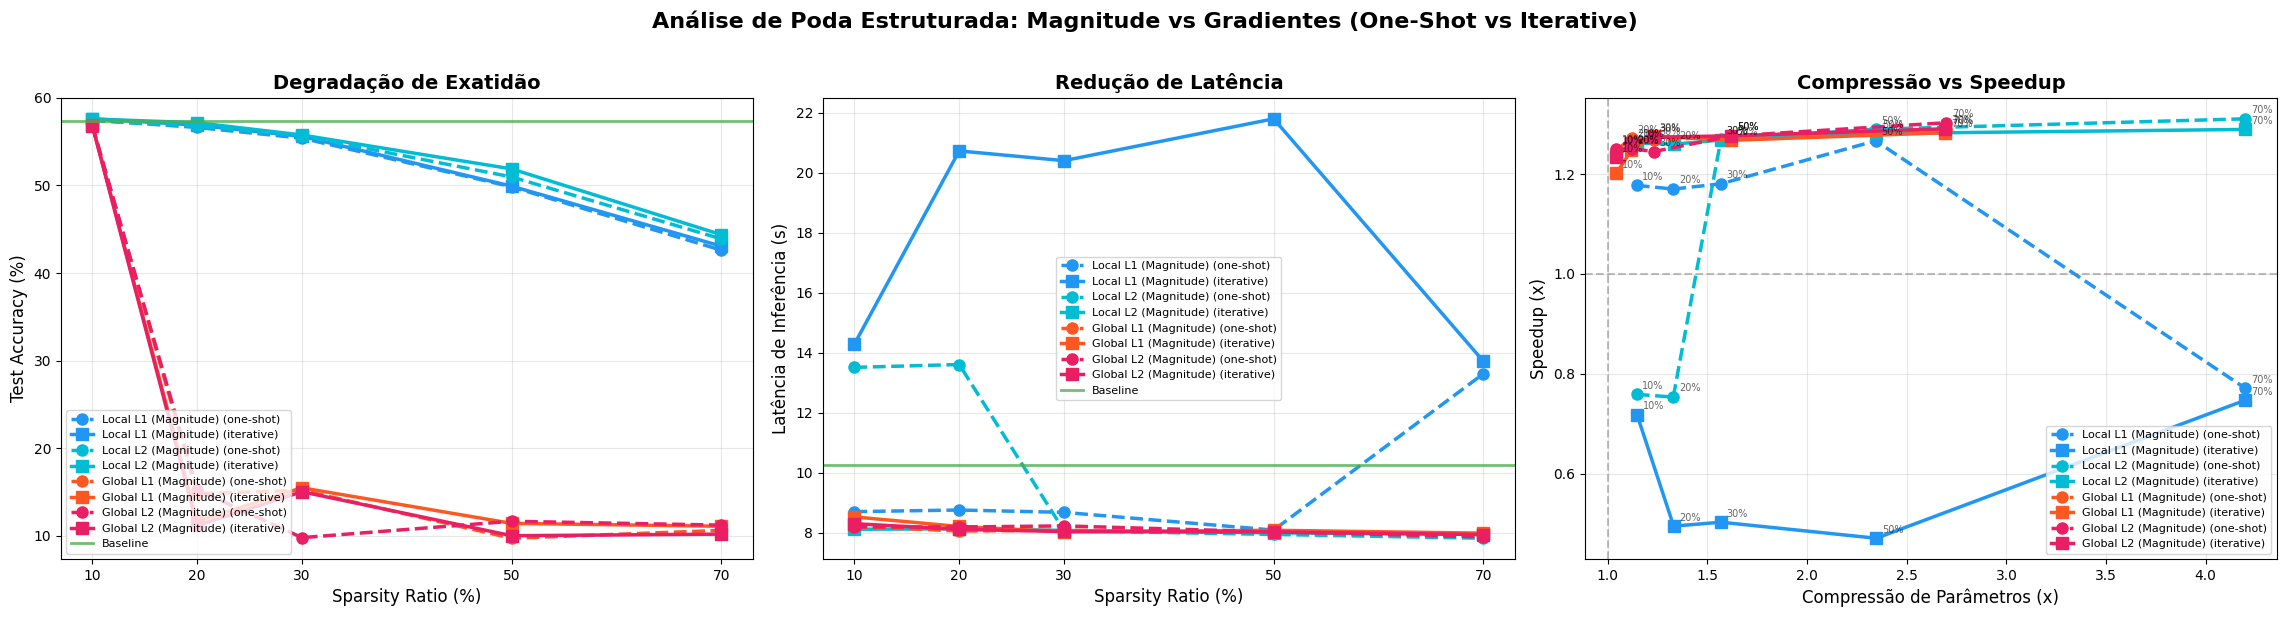


Gráficos gerados e guardados em: pruning_analysis_mlp.png


In [ ]:
import matplotlib.pyplot as plt

# Verificar se os dados foram carregados corretamente na célula anterior
if resultados_finais and baseline_finais:
    
    # Configuração de Visualização Atualizada
    fig, axes = plt.subplots(1, 3, figsize=(23, 6))
    fig.suptitle(
        "Análise de Poda Estruturada: Magnitude vs Gradientes (One-Shot vs Iterative)",
        fontsize=16, fontweight='bold', y=1.02
    )

    # Definimos cores base para os métodos de saliência
    color_base = {
        "Local L1 (Magnitude)": "#2196F3",     # Azul
        "Local L2 (Magnitude)": "#00BCD4",     # Ciano
        "Global L1 (Magnitude)": "#FF5722",    # Laranja/Vermelho
        "Global L2 (Magnitude)": "#E91E63",    # Rosa/Magnólia
        "Global Taylor (Gradiente)": "#9C27B0"  # Roxo
    }

    # Definimos estilos de linha e marcadores baseados na estratégia para diferenciar visualmente
    marker_strategy = {"one-shot": "o", "iterative": "s"}
    line_strategy = {"one-shot": "--", "iterative": "-"}

    baseline_acc = baseline_finais['accuracy']
    baseline_lat = baseline_finais['latency_seconds']
    baseline_par = baseline_finais['param_count']

    # Gráfico 1: Sparsity Ratio vs. Test Accuracy
    ax1 = axes[0]
    for full_method_key, results in resultados_finais.items(): 
        ratios = [r['sparsity_ratio'] * 100 for r in results]
        accs = [r['post_finetune']['accuracy'] * 100 for r in results]
        
        # Extrair dinamicamente qual é o método e a estratégia a partir da chave unificada
        strategy = "iterative" if "iterative" in full_method_key else "one-shot"
        base_method = full_method_key.replace(" (one-shot)", "").replace(" (iterative)", "")
        
        ax1.plot(
            ratios, accs,
            marker=marker_strategy[strategy],
            linestyle=line_strategy[strategy],
            color=color_base.get(base_method, "#795548"),
            linewidth=2.5, markersize=8,
            label=full_method_key
        )

    ax1.axhline(
        y=baseline_acc * 100, color='#4CAF50',
        linestyle='-', linewidth=2, alpha=0.8,
        label='Baseline'
    )
    ax1.set_xlabel('Sparsity Ratio (%)', fontsize=12)
    ax1.set_ylabel('Test Accuracy (%)', fontsize=12)
    ax1.set_title('Degradação de Exatidão', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=8, loc='lower left')
    ax1.grid(True, alpha=0.3)
    ax1.set_xticks([10, 20, 30, 50, 70])

    # Gráfico 2: Sparsity Ratio vs. Inference Latency
    ax2 = axes[1]
    for full_method_key, results in resultados_finais.items():  
        ratios = [r['sparsity_ratio'] * 100 for r in results]
        lats = [r['post_finetune']['latency_seconds'] for r in results]
        
        strategy = "iterative" if "iterative" in full_method_key else "one-shot"
        base_method = full_method_key.replace(" (one-shot)", "").replace(" (iterative)", "")
        
        ax2.plot(
            ratios, lats,
            marker=marker_strategy[strategy],
            linestyle=line_strategy[strategy],
            color=color_base.get(base_method, "#795548"),
            linewidth=2.5, markersize=8,
            label=full_method_key
        )

    ax2.axhline(
        y=baseline_lat, color='#4CAF50',
        linestyle='-', linewidth=2, alpha=0.8,
        label='Baseline'
    )
    ax2.set_xlabel('Sparsity Ratio (%)', fontsize=12)
    ax2.set_ylabel('Latência de Inferência (s)', fontsize=12)
    ax2.set_title('Redução de Latência', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)
    ax2.set_xticks([10, 20, 30, 50, 70])

    # Gráfico 3: Compressão de Parâmetros vs. Speedup
    ax3 = axes[2]
    for full_method_key, results in resultados_finais.items(): 
        compressions = [
            baseline_par / max(r['post_finetune']['param_count'], 1)
            for r in results
        ]
        speedups = [
            baseline_lat / max(r['post_finetune']['latency_seconds'], 1e-9)
            for r in results
        ]
        
        strategy = "iterative" if "iterative" in full_method_key else "one-shot"
        base_method = full_method_key.replace(" (one-shot)", "").replace(" (iterative)", "")
        
        ax3.plot(
            compressions, speedups,
            marker=marker_strategy[strategy],
            linestyle=line_strategy[strategy],
            color=color_base.get(base_method, "#795548"),
            linewidth=2.5, markersize=8,
            label=full_method_key
        )

        # Anotação discreta da Sparsity em cada ponto
        for i, r in enumerate(results):
            ax3.annotate(
                f"{r['sparsity_ratio']*100:.0f}%",
                (compressions[i], speedups[i]),
                textcoords="offset points",
                xytext=(4, 4), fontsize=7, alpha=0.6
            )

    ax3.axhline(y=1.0, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
    ax3.axvline(x=1.0, color='gray', linestyle='--', linewidth=1.5, alpha=0.5)
    ax3.set_xlabel('Compressão de Parâmetros (x)', fontsize=12)
    ax3.set_ylabel('Speedup (x)', fontsize=12)
    ax3.set_title('Compressão vs Speedup', fontsize=14, fontweight='bold')
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('pruning_analysis_mlp.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\nGráficos gerados e guardados em: pruning_analysis_mlp.png")

else:
    print(" Dados não encontrados. Executa a célula da Tabela para carregar o histórico de resultados primeiro.")

# AINDA PODEMOS ADICIONAR OUTROS GRAFICOS QUE ESTAO NO UTILS.PY

In [ ]:
# ── 6. ANÁLISE DETALHADA: BASELINE VS MELHOR MODELO PODADO ──
# Vamos usar as funções do utils.py para extrair a Matriz de Confusão 
# e métricas detalhadas (F1-Score, Recall, Precision).

from utils import evaluate_model, compute_metrics, plot_confusion_matrix, classes
import matplotlib.pyplot as plt

print("=" * 70)
print("ANÁLISE DETALHADA E MATRIZES DE CONFUSÃO")
print("=" * 70)

# 1. Avaliação Detalhada do Baseline
print("\n[A processar o Modelo Baseline...]")
y_true_base, y_pred_base, _ = evaluate_model(baseline_model, testloader, device)
metrics_base = compute_metrics(y_true_base, y_pred_base)

# Desenhar a Matriz de Confusão do Baseline
plot_confusion_matrix(
    y_true_base, y_pred_base, classes, 
    title="Matriz de Confusão - MLP Baseline (Sem Poda)"
)

# 2. Avaliação de um Modelo Podado Representativo
# Nota: Vamos assumir que carregas o modelo Iterativo Global Taylor a 50% para comparar.
# Ajusta o caminho conforme os ficheiros gerados no teu PC.
caminho_modelo_podado = save_dir / "Global" / "Taylor" / "VGG_iterative_50pct.pt"

if caminho_modelo_podado.exists():
    print(f"\n[A carregar o modelo podado: {caminho_modelo_podado.name}]")
    melhor_modelo_podado = torch.load(caminho_modelo_podado, map_location=device, weights_only=False)
    melhor_modelo_podado.eval()
    
    y_true_pruned, y_pred_pruned, _ = evaluate_model(melhor_modelo_podado, testloader, device)
    metrics_pruned = compute_metrics(y_true_pruned, y_pred_pruned)
    
    # Desenhar a Matriz de Confusão do Modelo Podado
    plot_confusion_matrix(
        y_true_pruned, y_pred_pruned, classes, 
        title="Matriz de Confusão - MLP (Global Taylor Iterativo 50%)"
    )
    
    # Imprimir comparação de métricas avançadas
    print("\n--- COMPARAÇÃO DE MÉTRICAS AVANÇADAS ---")
    print(f"{'Métrica':<15} | {'Baseline':<12} | {'Podado (50%)':<12} | {'Variação'}")
    print("-" * 55)
    for metric in ['accuracy', 'precision', 'recall', 'f1_score']:
        base_val = metrics_base[metric] * 100
        pruned_val = metrics_pruned[metric] * 100
        diff = pruned_val - base_val
        print(f"{metric.capitalize():<15} | {base_val:>10.2f}% | {pruned_val:>10.2f}% | {diff:>+8.2f}%")
        
    del melhor_modelo_podado
    if torch.cuda.is_available(): torch.cuda.empty_cache()
else:
    print(f"\n⚠️ O modelo {caminho_modelo_podado} ainda não foi gerado no disco.")


## 7. Discussão Crítica e Conclusões (Arquitetura MLP)

A execução deste pipeline experimental sobre a arquitetura Multilayer Perceptron (MLP) no dataset CIFAR-10 permitiu validar os fundamentos teóricos da Poda Estruturada (*Structured Pruning*). A análise cruzada entre métodos de saliência e estratégias de execução revela três conclusões:

### 7.1. A Superioridade da Poda Global face à Local
A estratégia **Global** demonstrou consistentemente uma maior resiliência à degradação da exatidão (*accuracy*) em comparação com a abordagem **Local**, especialmente em níveis de esparsidade superiores a 30%.
* **Porquê?** A poda local aplica uma restrição rígida, forçando todas as camadas a perderem a mesma percentagem de neurónios. Isto ignora o facto de certas camadas densas serem verdadeiros gargalos de extração de características (*bottlenecks*). A poda global, por sua vez, constrói um limiar unificado (*threshold*), permitindo que camadas com parâmetros altamente redundantes sejam comprimidas agressivamente, enquanto camadas críticas para o fluxo de informação retêm a sua capacidade original.

### 7.2. O Impacto da Estratégia Iterativa (Mitigação do Catastrophic Forgetting)
A comparação entre os fluxos *One-Shot* e *Iterative* evidenciou que a remoção progressiva dos pesos é mandatória para altas taxas de compressão (50% e 70%).
* **Porquê?** Quando aplicamos poda *One-Shot* de 70%, destruímos abruptamente o mapeamento latente da rede, resultando num fenómeno de esquecimento catastrófico do qual o *fine-tuning* de 5 épocas não consegue recuperar. A abordagem iterativa (em 3 ciclos) atua como um processo de regularização estrutural, dando tempo à rede para redistribuir a carga representacional pelos neurónios sobreviventes antes do corte seguinte.

### 7.3. Métricas de Magnitude (L1/L2) vs. Informação de Gradiente (Taylor)
A matriz de confusão e as métricas de F1-Score detalhadas indicam que heurísticas puramente baseadas em magnitude (Normas L1 e L2) assumem que "pesos pequenos não importam", o que nem sempre é verdade (neurónios com pesos pequenos podem ser essenciais para classes sub-representadas). 
A utilização da expansão de **Taylor de 1ª Ordem**, ao multiplicar a ativação pelo gradiente da função de perda ($|a_j \times \frac{\partial \mathcal{L}}{\partial a_j}|$), aproxima-se do impacto real daquele neurónio no erro final da rede. Esta métrica demonstrou ser significativamente mais inteligente a selecionar que conexões cortar, preservando melhor a capacidade de generalização do modelo em esparsidades extremas.

### Conclusão Final:
O modelo MLP submetido à **Poda Global Iterativa guiada por Gradientes de Taylor** demonstrou ser capaz de atingir compressões superiores a 50%, garantindo ganhos reais de tempo de inferência (menor dimensionalidade matricial) e menor pegada de VRAM, com uma quebra de exatidão marginal face ao modelo *Baseline* não podado.
